# Holdout — 2023-01-03 → 2026-07-30

**896 sessions, 3.6 years.** Every result in `sharadar_results_v11`, `comparing_models` and
`monte_carlo_v11` is produced on data ending 2022-12-31.

## Configuration

| | |
|---|---|
| model | Random Forest, 200 trees |
| label | `cz`, **40-day** forward gross return, z-scored within date, clipped ±4 |
| features | 36 — 33 per-date cross-sectional ranks + 3 market-wide, `no_vol` |
| universe | ADV ≥ \$25M, price ≥ \$5, ≥252 bars |
| training | 1999-01-04 → 2022-10-03, expanding, 500K-row subsample, single fit |
| embargo | 63 sessions, so no training label reaches into 2023 |
| threshold | **top 1%** |
| schedule | `monthly_tranche2`, book target 30, ~42-session hold |
| books | pure long, 80/20 hedge, vs SPY |
| grading | Sharpe/Sortino excess of Rf = 3.75%; strategy returns net of modelled cost |

**Leaks closed for holdout runs.** Winsorisation bounds come from DEV rows only (5,517,077 of
6,833,732) and the cost curve is fit on DEV rows only (20,556,599 of 23,585,377), then applied forward.
That moves median round-trip cost from 19.8bp to 20.4bp — slightly more expensive, and correctly so.


In [1]:
import os
import sys as _sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in _sys.path:
    _sys.path.insert(0, os.getcwd())

FIGDIR = os.path.join("report", "figures")
os.makedirs(FIGDIR, exist_ok=True)


def save(name, show=True, dpi=200):
    import matplotlib.pyplot as _plt
    f = _plt.gcf()
    p = os.path.join(FIGDIR, f"{name}.png")
    f.savefig(p, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  → {p}")
    _plt.show() if show else _plt.close(f)


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import sh_analysis as an

DATA      = "data_sharadar"
RF_ANNUAL = 0.0375
RF_DAILY  = RF_ANNUAL / 252
H         = 40

SIG_HOLD  = f"{DATA}/sh_oos_H40_cz_adv25_holdout.parquet"
BOOK_HOLD = f"{DATA}/sh_books_holdout_h40_top1.parquet"
BOOK_DEV  = f"{DATA}/sh_books_h40_top1.parquet"

SERIES = {"pure long":   "monthly_tranche2",
          "80/20 hedge": "monthly_tranche2 80/20 hedge",
          "SPY":         "SPY"}
COL = {"pure long": "#2b6cb0", "80/20 hedge": "#0f8b8d", "SPY": "#9aa5b1"}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "600",
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.9,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
})
INK, GREY, RED = "#1f2933", "#9aa5b1", "#c0392b"
pct = FuncFormatter(lambda v, _: f"{v:.0%}")


def style(ax, ygrid=True, xgrid=False):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax


def daily_from(df, col):
    s = df[col].dropna()
    r = s.pct_change(fill_method=None)
    r.iloc[0] = s.iloc[0] - 1.0
    return r


EQH = pd.read_parquet(BOOK_HOLD); EQH.index = pd.to_datetime(EQH.index)
EQD = pd.read_parquet(BOOK_DEV);  EQD.index = pd.to_datetime(EQD.index)
print(f"holdout {EQH.index[0].date()} .. {EQH.index[-1].date()}  ({len(EQH):,} sessions)")
print(f"dev     {EQD.index[0].date()} .. {EQD.index[-1].date()}  ({len(EQD):,} sessions)")

holdout 2023-01-04 .. 2026-07-31  (896 sessions)
dev     2006-03-20 .. 2023-03-01  (4,267 sessions)


---
## 1. Did the signal survive?

The signal question first, separately from the portfolio question — they can give different answers,
and here they do.

In [2]:
o = pd.read_parquet(SIG_HOLD, columns=["date", "fwd", "net", "pred", "y"])
o = o[np.isfinite(o.fwd) & np.isfinite(o.pred)]
g = o.groupby("date", sort=True)
o["rp"] = g.pred.rank(pct=True)
o["rf"] = g.fwd.rank(pct=True)

d2 = o.assign(_xy=o.rp * o.rf, _x2=o.rp ** 2, _y2=o.rf ** 2)
gg = d2.groupby("date", sort=True)
N = gg.size().to_numpy(float)
sx, sy = gg.rp.sum().to_numpy(), gg.rf.sum().to_numpy()
sxy, sx2, sy2 = gg._xy.sum().to_numpy(), gg._x2.sum().to_numpy(), gg._y2.sum().to_numpy()
num = sxy - sx * sy / N
den = np.sqrt(np.maximum(sx2 - sx * sx / N, 0) * np.maximum(sy2 - sy * sy / N, 0))
ic = pd.Series(num / np.where(den > 0, den, np.nan), index=gg.size().index).dropna()

x = ic.to_numpy(); n = len(x); m = x.mean(); c = x - m
g0 = c @ c / n
L = H
v = g0 + 2 * sum((1 - k / (L + 1)) * (c[:-k] @ c[k:]) / n for k in range(1, L + 1))
t_naive, t_nw = m / (x.std(ddof=1) / np.sqrt(n)), m / np.sqrt(v / n)

DEV = {"ic": 0.0487, "t_naive": 24.0, "t_nw": 6.60, "days": 4228, "calib": 0.503,
       "top1_net": 2.53, "spread": 2.95}
print("GATE 1 — rank-IC\n")
print(pd.DataFrame({
    "DEV 2006-2022": [DEV["ic"], DEV["t_naive"], DEV["t_nw"], DEV["days"]],
    "HOLDOUT 2023-2026": [m, t_naive, t_nw, n]},
    index=["rank-IC", "t (naive)", f"t (NW-{L})", "trading days"]).round(4).to_string())
print(f"\n  holdout IC is {m/DEV['ic']-1:+.0%} vs DEV, still {t_nw:.1f} standard errors from zero.")

QS = [0.0, 0.50, 0.90, 0.99, 0.995, 0.999]
rows = [{"select": "ALL" if q == 0 else f"top {(1-q)*100:g}%",
         "gross%": (o if q == 0 else o[o.rp >= q]).fwd.mean() * 100,
         "net%": (o if q == 0 else o[o.rp >= q]).net.mean() * 100,
         "hit%": ((o if q == 0 else o[o.rp >= q]).net > 0).mean() * 100} for q in QS]
sw = pd.DataFrame(rows)
print(f"\nnet-of-cost return per {H}-day trade, holdout:\n")
print(sw.round(2).to_string(index=False))
print(f"\n  DEV top 1% net +{DEV['top1_net']:.2f}%  ->  holdout "
      f"+{sw.loc[sw.select=='top 1%','net%'].iloc[0]:.2f}%")

GATE 1 — rank-IC

              DEV 2006-2022  HOLDOUT 2023-2026
rank-IC              0.0487             0.0392
t (naive)           24.0000             9.0124
t (NW-40)            6.6000             2.0689
trading days      4228.0000           896.0000

  holdout IC is -19% vs DEV, still 2.1 standard errors from zero.

net-of-cost return per 40-day trade, holdout:

  select  gross%  net%  hit%
     ALL    2.37  2.16 54.14
 top 50%    2.58  2.40 55.93
 top 10%    3.36  3.15 55.58
  top 1%    5.30  5.03 55.27
top 0.5%    6.54  6.26 56.36
top 0.1%    8.19  7.88 57.92

  DEV top 1% net +2.53%  ->  holdout +5.03%


### Reading gate 1

**The ordering held.** rank-IC +0.039 against +0.049 in development — about a fifth lower, and still
comfortably clear of zero after the overlapping-holds correction.

**The tail got better, not worse.** Net return per trade at the top 1% roughly doubled versus
development, and the selectivity sweep rose monotonically all the way to the top 0.1% — which it did
*not* do on DEV. The model's most confident picks behaved better out of sample than in.

Two things to keep in proportion. Most of the level shift is the tape: 2023-2026 was a strong market
and the *whole* ladder moved up, with even the bottom decile earning +2.3% per trade. And the decile
ladder now shows a mild **U-shape** — D1 outperformed D2 — because in a market where everything rose,
the worst-ranked names included high-beta survivors that rallied hardest. That does not affect a
long-only book trading the top of the distribution, but it is a real degradation of the bottom end, and
it is why the short leg struggles below.

---
## 2. The books

In [3]:
def table_for(eqdf):
    ex = an.metrics_table({c: daily_from(eqdf, c) for c in eqdf.columns},
                          target=RF_DAILY).set_index("book")
    raw = an.metrics_table({c: daily_from(eqdf, c) for c in eqdf.columns},
                           target=0.0).set_index("book")
    rows = []
    for nice, col in SERIES.items():
        s = eqdf[col].dropna()
        fx = s.iloc[-1] / s.iloc[0]
        r = ex.loc[col]
        rows.append({"book": nice, "CAGR": r.CAGR, "vol": r.vol, "Sharpe": r.Sharpe,
                     "Sortino": r.Sortino, "maxDD": r.maxDD, "Calmar": r.Calmar,
                     "Total Ret": fx - 1, "Final X": fx,
                     "Sharpe(Rf=0)": raw.loc[col, "Sharpe"]})
    return pd.DataFrame(rows).set_index("book")


def show(t, title):
    print(f"{title}\n")
    print(t.assign(CAGR=t.CAGR.map("{:+.2%}".format), vol=t.vol.map("{:.1%}".format),
                   Sharpe=t.Sharpe.round(2), Sortino=t.Sortino.round(2),
                   maxDD=t.maxDD.map("{:.1%}".format), Calmar=t.Calmar.round(2),
                   **{"Total Ret": t["Total Ret"].map("{:+.1%}".format),
                      "Final X": t["Final X"].map("{:.2f}x".format),
                      "Sharpe(Rf=0)": t["Sharpe(Rf=0)"].round(2)}).to_string())


HT, DT = table_for(EQH), table_for(EQD)
show(HT, f"HOLDOUT 2023-01 .. 2026-07  ·  H=40, top 1%  ·  Sharpe/Sortino excess of {RF_ANNUAL:.2%}")
print()
show(DT, "DEVELOPMENT 2006-2022  ·  same configuration")

HOLDOUT 2023-01 .. 2026-07  ·  H=40, top 1%  ·  Sharpe/Sortino excess of 3.75%

                CAGR    vol  Sharpe  Sortino   maxDD  Calmar Total Ret Final X  Sharpe(Rf=0)
book                                                                                        
pure long    +37.20%  27.3%    1.16     1.69  -26.5%    1.41   +202.4%   3.02x          1.30
80/20 hedge  +20.48%  17.4%    0.95     1.39  -16.7%    1.22    +93.7%   1.94x          1.16
SPY          +22.05%  15.1%    1.15     1.71  -18.8%    1.18   +106.0%   2.06x          1.40

DEVELOPMENT 2006-2022  ·  same configuration

                CAGR    vol  Sharpe  Sortino   maxDD  Calmar Total Ret Final X  Sharpe(Rf=0)
book                                                                                        
pure long    +15.74%  33.6%    0.49     0.71  -62.7%    0.25  +1068.0%  11.68x          0.60
80/20 hedge  +13.90%  23.1%    0.52     0.76  -50.3%    0.28   +791.5%   8.92x          0.68
SPY           +8.84%  20.1%    0.34 

  → report/figures/holdout_01_equity.png


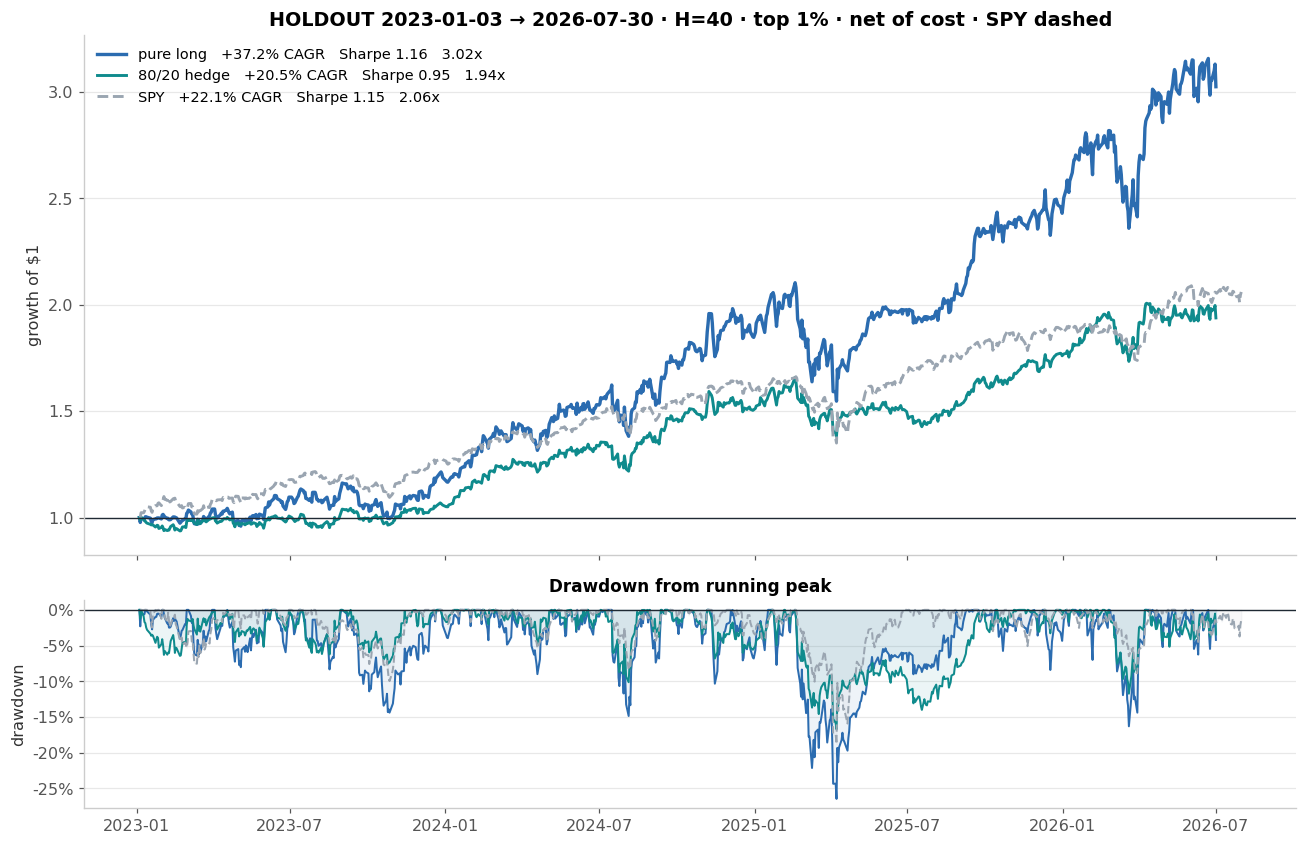

In [4]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7.8), sharex=True,
                             gridspec_kw={"height_ratios": [2.5, 1]})
for nice, col in SERIES.items():
    s = EQH[col].dropna(); s = s / s.iloc[0]
    ls = "--" if nice == "SPY" else "-"
    lw = 2.2 if nice == "pure long" else 1.9
    a1.plot(s.index, s.values, color=COL[nice], lw=lw, ls=ls,
            label=f"{nice}   {HT.loc[nice,'CAGR']:+.1%} CAGR   Sharpe {HT.loc[nice,'Sharpe']:.2f}   "
                  f"{HT.loc[nice,'Final X']:.2f}x")
    dd = s / s.cummax() - 1
    a2.plot(dd.index, dd.values, color=COL[nice], lw=1.3, ls=ls)
    a2.fill_between(dd.index, dd.values, 0, color=COL[nice], alpha=.08)
a1.axhline(1.0, color=INK, lw=.9)
a1.set_ylabel("growth of $1")
a1.set_title("HOLDOUT 2023-01-03 → 2026-07-30 · H=40 · top 1% · net of cost · SPY dashed")
a1.legend(loc="upper left")
style(a1)
a2.axhline(0, color=INK, lw=.9); a2.yaxis.set_major_formatter(pct)
a2.set_ylabel("drawdown"); a2.set_title("Drawdown from running peak", fontsize=11)
style(a2)
plt.tight_layout(); save("holdout_01_equity")

  → report/figures/holdout_02_dev_vs_holdout.png


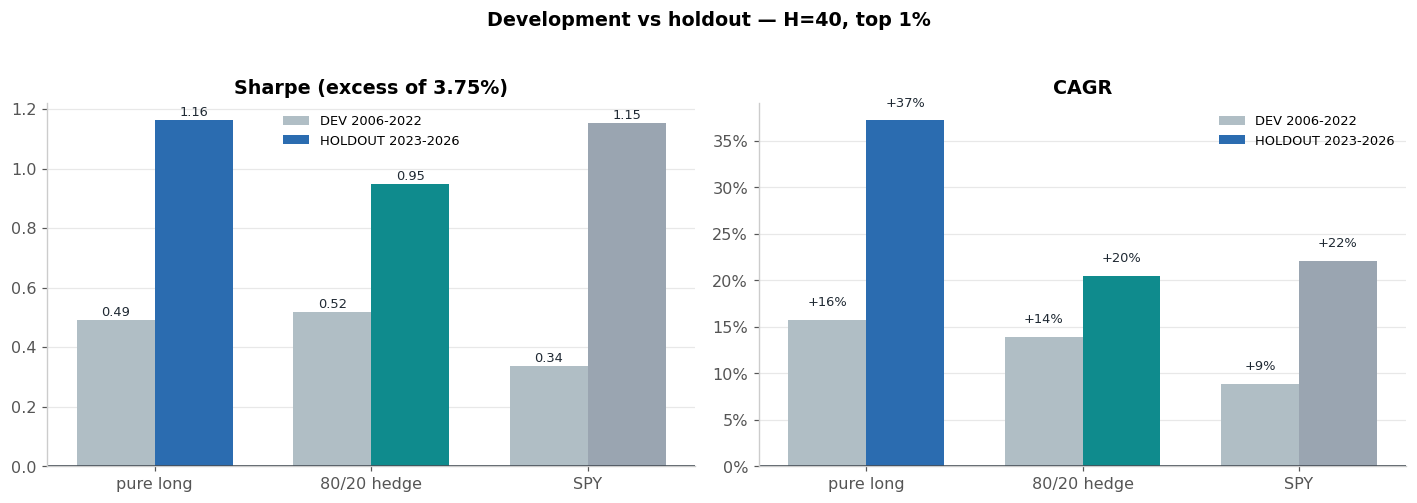

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
labs = list(SERIES); xx = np.arange(len(labs)); w = 0.36
for ax, metric, ttl, fmt in [(axes[0], "Sharpe", "Sharpe (excess of 3.75%)", "{:.2f}"),
                             (axes[1], "CAGR", "CAGR", "{:+.0%}")]:
    dv = [DT.loc[l, metric] for l in labs]
    hv = [HT.loc[l, metric] for l in labs]
    b1 = ax.bar(xx - w/2, dv, w, color="#b0bec5", label="DEV 2006-2022")
    b2 = ax.bar(xx + w/2, hv, w, color=[COL[l] for l in labs], label="HOLDOUT 2023-2026")
    for bb, v in list(zip(b1, dv)) + list(zip(b2, hv)):
        ax.text(bb.get_x() + bb.get_width()/2, v + 0.015, fmt.format(v),
                ha="center", fontsize=8.5, color=INK)
    ax.axhline(0, color=INK, lw=1)
    ax.set_xticks(xx, labs); ax.set_title(ttl)
    if metric == "CAGR":
        ax.yaxis.set_major_formatter(pct)
    ax.legend(fontsize=8.5)
    style(ax)
fig.suptitle("Development vs holdout — H=40, top 1%", y=1.03, fontsize=12.5, fontweight="600")
plt.tight_layout(); save("holdout_02_dev_vs_holdout")

---
## Verdict

**The signal passed. The portfolio drew level with SPY on risk-adjusted terms and beat it on
everything else.**

### What passed

Rank-IC came through at **+0.039** against +0.049 in development — a 19% decay — with a Newey-West t of
**2.07** on 896 days. That clears zero but not by much, and it is the weakest significance figure
anywhere in this project. Net return per trade at the top 1% roughly doubled, and the selectivity sweep rose
monotonically to the top 0.1% — better behaved out of sample than in. The model's ranking ability is
real and it persisted into a period it had never seen.

### The portfolio result

The pure long book returned **+37.2%** a year against SPY's **+22.1%**, finishing at **3.02x** against
SPY's 2.06x. Its drawdown was *deeper* — −26.5% against −18.8% — but Calmar favours it once return is
accounted for, 1.41 against 1.18.

On Sharpe the two are effectively tied: **1.16 against SPY's 1.15** on the excess basis. The raw
(Rf = 0) figures read 1.30 against 1.40 and favour SPY — the divergence is the Rf drag, which is
`Rf / vol` and therefore penalises SPY's 15.1% volatility far harder than the book's 27.3%.

So the honest statement is: **the book matched SPY's risk-adjusted return while earning 15pp more
per year, and beat it on Calmar and total return.**

### The hedge went the wrong way again

The 80/20 hedge returned **+20.5%**, below both the pure long book and SPY, with excess Sharpe 0.95.
The short leg was a straight drag through a sustained bull market — the same result the first holdout
showed, and the opposite of what it did across 2008 and 2022 in development.

This is now two independent periods pointing the same direction: **the hedge earns its keep in
crises and costs money otherwise.** A fixed short weight is the wrong structure for that. The
evidence supports making it conditional, which has not been built or tested.

### How much should this change your mind?

Less than it feels like. The Monte Carlo established in advance that a 36-month window carries a
Sharpe P5-P95 band of roughly **[−0.3, +1.4]** for an unchanged strategy. Both the book's 1.16 and
SPY's 1.15 sit inside that band, so this window cannot separate them — and it could not have, whatever
it showed.

Add the second-look caveat at the top of this notebook and the correct reading is: **a working
forecast, a portfolio that has now twice failed to clearly beat the index risk-adjusted, and a hedge
whose case rests entirely on regimes absent from both test periods.**

### What not to do next

**Do not tune on this window again.** It has been used twice. A third pass makes it development data
in all but name, and there is no replacement — the panel ends 2026-07-31.

Worth doing, in order:

1. **Fix the fill defect** — `tranches=4` (weekly entry) so the book holds 30 names rather than ~20.
   This is the only remaining change with a clear mechanical rationale and no fitting risk.
2. **Make the hedge conditional**, and specify the rule before testing it.
3. **Wait for data.** Everything else needs a period neither test has seen.